In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
df = pd.read_csv('train.csv')

In [5]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
# 42000 images
# 28 * 28 = 784 pixels
# 1 lable
df.shape

(42000, 785)

In [7]:
# 1250 is 4
df.iloc[1250,0]

np.int64(4)

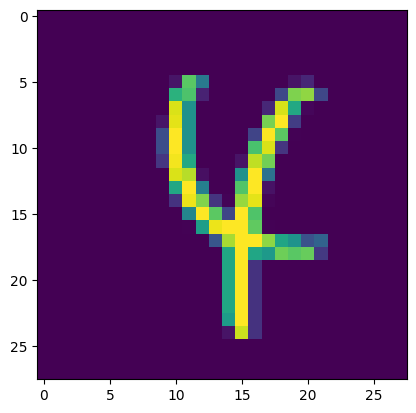

In [8]:
import matplotlib.pyplot as plt
plt.imshow(df.iloc[1250,1:].values.reshape(28,28))

### here we try to achieve some accu using KNN algorithm before using PCA

In [9]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [12]:
 import time
 start = time.time()
 y_pred = knn.predict(X_test)
print(time.time() - start)

13.61181378364563


**see above we almost take 11 sec for prediction because we have 784 dimension and for prediction we use to calculate all points with all that why we need PCA to reduce its dimension**

In [13]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.9648809523809524


**we got 96 % accu**

## Now we use PCA and try to achieve same acc using less number of features

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# now we scale and mean center the data
# fit_transform for learing one time the mean and std for scaling
# again we only call transform not fit because we use same paramereter in test data also
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=100)  # n_component how many component none means same as column

In [16]:
# projecting or transorming the data to pca components
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [17]:
X_train_trf.shape

(33600, 100)

### now we again train wid KNN using 100 pca comopnents

In [18]:
knn = KNeighborsClassifier()
knn.fit(X_train_trf, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [19]:
import time
start = time.time()
y_pred = knn.predict(X_test_trf)
print(time.time() - start)

4.133558511734009


**see now it takes only 1.5 sec rather 11 sec onl previos 784 dimension**

In [20]:
# 0.9648809523809524
print(accuracy_score(y_test, y_pred))

0.9544047619047619


last accur is 96 here we are getting 95 not bad we remove 684 dimension

### here we are using loop to find the least component needed to acehive 96% accu

In [21]:
 for i in range(1,784):
    pca = PCA(n_components=i)

    X_train_trf = pca.fit_transform(X_train)
    X_test_trf = pca.transform(X_test)

    knn = KNeighborsClassifier()
    knn.fit(X_train_trf, y_train)

    y_pred = knn.predict(X_test_trf)

    acuu = accuracy_score(y_test, y_pred)

    print(i, acuu)

    if acuu >= 0.95:
         break

1 0.2580952380952381
2 0.3236904761904762
3 0.5104761904761905
4 0.6663095238095238
5 0.7378571428571429
6 0.8227380952380953
7 0.8436904761904762
8 0.8721428571428571
9 0.886547619047619
10 0.9055952380952381
11 0.9116666666666666
12 0.9184523809523809
13 0.9276190476190476
14 0.9351190476190476
15 0.9384523809523809
16 0.9379761904761905
17 0.9407142857142857
18 0.94
19 0.9425
20 0.9442857142857143
21 0.9438095238095238
22 0.9441666666666667
23 0.9442857142857143
24 0.9457142857142857
25 0.9484523809523809
26 0.9479761904761905
27 0.9478571428571428
28 0.9471428571428572
29 0.949047619047619
30 0.9491666666666667
31 0.9507142857142857


**so we need atleast 31 pca component to acehive 95% acc**

## Now we visulize using 2 components

In [22]:
pca = PCA(n_components=2)

X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

X_train_trf.shape

(33600, 2)

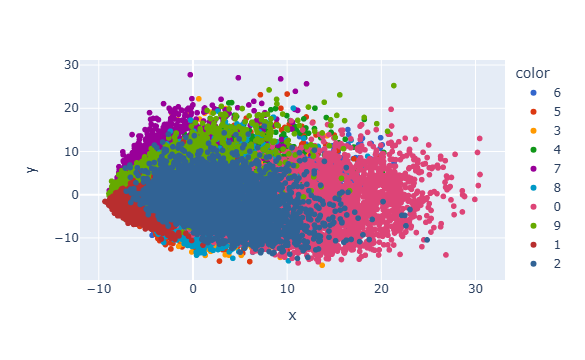

In [23]:
import plotly.express as px
y_train_trf = y_train.astype(str)

fig = px.scatter(x=X_train_trf[:,0],
                y = X_train_trf[:,1],
                color=y_train_trf,
                color_discrete_sequence=px.colors.qualitative.G10)

fig.show()

### Now visulize in 3D

In [24]:
pca = PCA(n_components=3)

X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

X_train_trf.shape

(33600, 3)

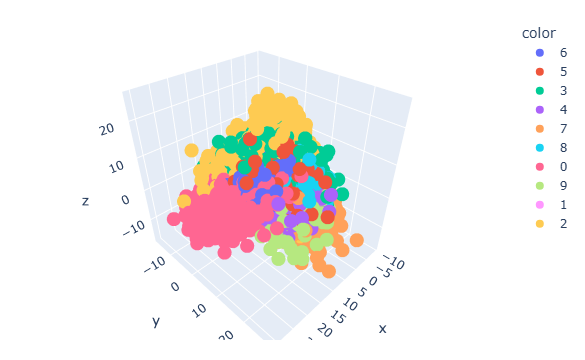

In [25]:
y_train_trf = y_train.astype(str)

fig = px.scatter_3d(x=X_train_trf[:,0],
                y = X_train_trf[:,1],
                z= X_train_trf[:,2],
                color=y_train_trf)
fig.update_layout(margin = dict(l=20, r =20, t=20, b=20))

fig.show()

In [26]:
# eigen values
pca.explained_variance_

array([40.67111198, 29.17023401, 26.74459621])

In [27]:
# eigen vector 
# 3 vector of 784 dimensions because we choose 3 pca component
pca.components_.shape

(3, 784)

## Now we use explaind variance method to find the optimum number of pca component

In [28]:
pca = PCA(n_components=None)

X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [29]:
# total 784 eigen values
pca.explained_variance_ratio_[:10]

array([0.05785192, 0.0414927 , 0.03804239, 0.02966263, 0.02581562,
       0.0225498 , 0.01973068, 0.0177528 , 0.01568651, 0.01436063])

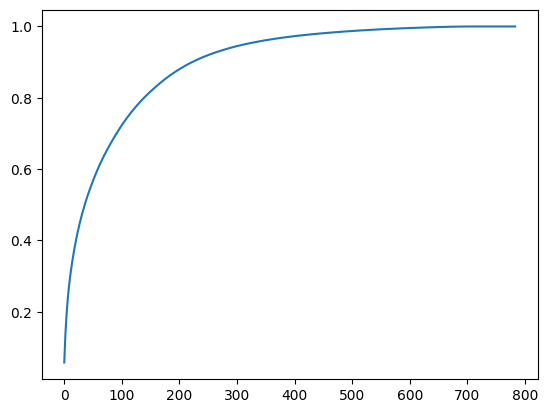

In [30]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))

**we can see and tell that 300 would get us 95 % if we use all 784 dimension**